# Сегментация клиентов: кластерный анализ по шагам

**Управленческий вопрос.** Каким сегментам клиентов адресовать предложение
и почему «средний клиент» — не сегмент?

Код этой тетради написан ассистентом по промпту из файла
[`3.3.1_промпт.md`](3.3.1_промпт.md) и принят по проверкам — что пришлось
исправить, разобрано в конце тетради. Данные — учебная выборка из 3000
клиентов: возраст, доход, остаток, активность и доля цифровых операций.

Маршрут: сначала считаем «среднего клиента» и смотрим, сколько клиентов
на него похожи. Затем строим кластеры по двум признакам и по пяти —
и сравниваем, какие решения следуют из каждой картины.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

%matplotlib inline
matplotlib.rcParams["font.size"] = 11
matplotlib.rcParams["figure.figsize"] = (9, 5)

ACC, WARN, INK = "#20BA72", "#E4572E", "#2E3641"
ПАЛИТРА = ["#20BA72", "#1B7FD6", "#E4572E", "#8A63D2", "#C9A227"]


def оформить(ax, заголовок, x=None, y=None):
    ax.set_title(заголовок, fontsize=12.5, pad=12, fontweight="bold", color=INK)
    if x: ax.set_xlabel(x, fontsize=10.5)
    if y: ax.set_ylabel(y, fontsize=10.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="both", alpha=0.25)

## Шаг 1. Данные и «средний клиент»

Загружаем выборку и смотрим описательную статистику. Идентификатор клиента —
не признак, в расчёты он не входит.

In [2]:
клиенты = pd.read_csv("../data/clients/clients_sample.csv",
                      sep=";", decimal=",", encoding="utf-8-sig")
ПРИЗНАКИ = ["возраст", "доход_тыс_руб", "средний_остаток_тыс_руб",
            "операций_в_месяц", "доля_цифровых_операций"]
клиенты[ПРИЗНАКИ].describe().round(1)

,возраст,доход_тыс_руб,средний_остаток_тыс_руб,операций_в_месяц,доля_цифровых_операций
count,3000.0,3000.0,3000.0,3000.0,3000.0
mean,41.4,166.6,956.8,35.5,0.7
std,12.3,70.7,857.6,16.2,0.3
min,21.0,35.0,5.0,1.0,0.0
25%,29.0,98.0,129.0,22.0,0.7
50%,45.0,176.0,890.5,37.0,0.8
75%,52.0,227.0,1665.0,47.0,0.9
max,68.0,344.0,3643.0,85.0,1.0


In [3]:
средний = клиенты[ПРИЗНАКИ].mean()
print("Портрет «среднего клиента»:")
print(средний.round(1).to_string())

# сколько клиентов действительно похожи на этот портрет
рядом = клиенты[(клиенты["возраст"].between(средний["возраст"] - 4, средний["возраст"] + 4))
                & (клиенты["доход_тыс_руб"].between(средний["доход_тыс_руб"] * 0.85,
                                                    средний["доход_тыс_руб"] * 1.15))]
print(f"\nКлиентов в окрестности среднего (±4 года, ±15% дохода): "
      f"{len(рядом)} из {len(клиенты)} — {len(рядом) / len(клиенты):.1%}")

Портрет «среднего клиента»:
возраст                     41.4
доход_тыс_руб              166.6
средний_остаток_тыс_руб    956.8
операций_в_месяц            35.5
доля_цифровых_операций       0.7

Клиентов в окрестности среднего (±4 года, ±15% дохода): 54 из 3000 — 1.8%


Средние по базе описывают клиента, которого в базе почти нет: в окрестность
«среднего портрета» попадает около двух процентов выборки. Кампания,
адресованная такому портрету, адресована никому. Почему так — покажет
диаграмма рассеяния.

## Шаг 2. Нормировка и выбор числа кластеров

Признаки измерены в несопоставимых единицах: доход — сотни тысяч, доля
цифровых операций — от нуля до единицы. Без приведения к одному масштабу
расстояние между клиентами определял бы признак с самыми большими числами —
остаток, — а остальные не участвовали бы. Поэтому перед кластеризацией
признаки стандартизуются: из каждого вычитается среднее, результат делится
на стандартное отклонение.

Число кластеров выбирается «методом локтя»: инерция (сумма квадратов
расстояний до центров) падает с ростом k, и точка, где падение резко
замедляется, — разумный выбор k.

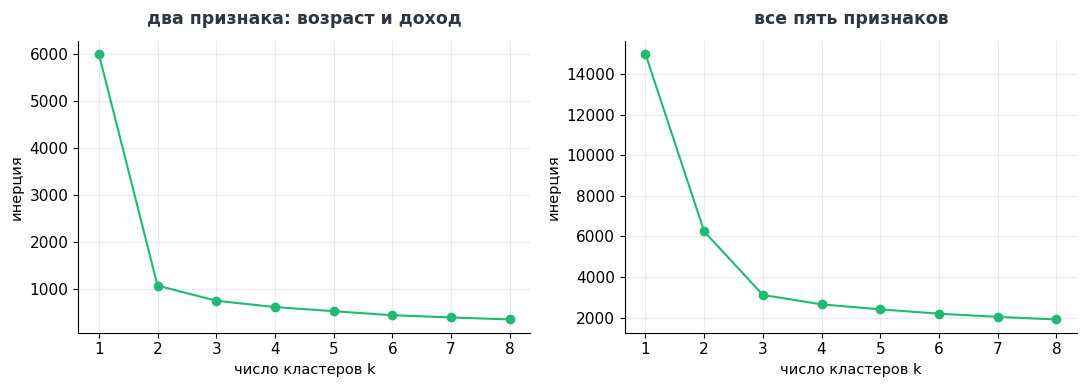

In [4]:
нормировщик = StandardScaler()
X5 = нормировщик.fit_transform(клиенты[ПРИЗНАКИ])
X2 = StandardScaler().fit_transform(клиенты[["возраст", "доход_тыс_руб"]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, X, имя in [(axes[0], X2, "два признака: возраст и доход"),
                   (axes[1], X5, "все пять признаков")]:
    инерция = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_
               for k in range(1, 9)]
    ax.plot(range(1, 9), инерция, marker="o", color=ACC)
    оформить(ax, имя, x="число кластеров k", y="инерция")
plt.tight_layout()
plt.show()

По двум признакам локоть на **k = 2**, по пяти — на **k = 3**. Это не
техническая деталь, а первый содержательный результат: в плоскости
«возраст — доход» видны два сегмента, но полные данные говорят, что их три.
Проверим оба варианта.

## Шаг 3. Кластеры на плоскости «возраст — доход»

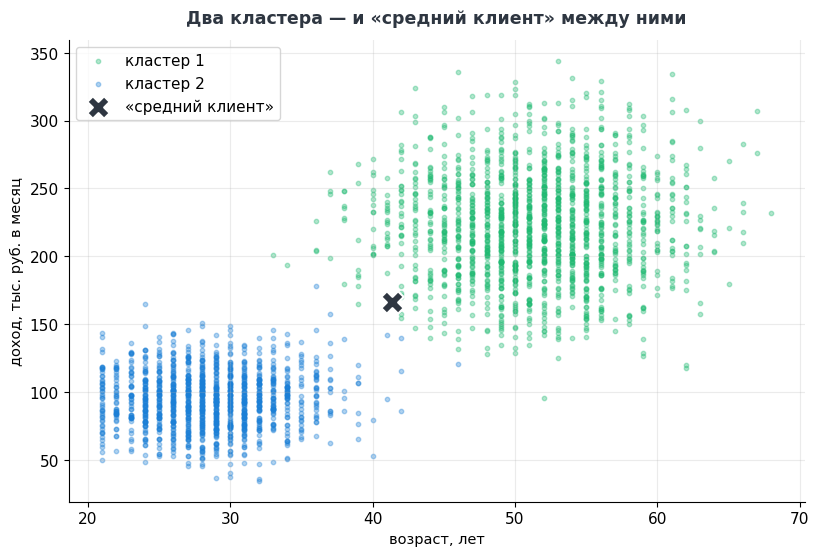

In [5]:
км2 = KMeans(n_clusters=2, random_state=42, n_init=10).fit(X2)
метки2 = км2.labels_

fig, ax = plt.subplots(figsize=(9.5, 6))
for k in range(2):
    m = метки2 == k
    ax.scatter(клиенты.loc[m, "возраст"], клиенты.loc[m, "доход_тыс_руб"],
               s=10, alpha=0.35, color=ПАЛИТРА[k], label=f"кластер {k + 1}")
ax.scatter(клиенты["возраст"].mean(), клиенты["доход_тыс_руб"].mean(),
           marker="X", s=260, color=INK, edgecolor="white", linewidth=1.5,
           zorder=5, label="«средний клиент»")
ax.legend(loc="upper left")
оформить(ax, "Два кластера — и «средний клиент» между ними",
         x="возраст, лет", y="доход, тыс. руб. в месяц")
plt.show()

Картина из банковской практики: молодые клиенты с невысоким доходом
и старшие состоятельные. «Средний клиент» — 41 год и 167 тысяч — лежит
в пустоте между облаками: гипотеза, построенная на среднем, промахивается
мимо обоих сегментов сразу.

Но у этой плоскости есть ограничение: она не различает, **как** состоятельные
клиенты пользуются банком. Добавим третье измерение.

## Шаг 4. Кластеры в трёх измерениях

Кластеризация — по всем пяти нормированным признакам; на графике — три
из них: возраст, доход и доля цифровых операций. График интерактивный,
его можно вращать мышью; он же сохраняется отдельным файлом
`3.3.4_кластеры_3d.html`.

In [6]:
import plotly.express as px

км5 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X5)
клиенты["кластер"] = (км5.labels_ + 1).astype(str)

fig = px.scatter_3d(
    клиенты.sort_values("кластер"),
    x="возраст", y="доход_тыс_руб", z="доля_цифровых_операций",
    color="кластер",
    color_discrete_sequence=ПАЛИТРА[:3],
    labels={"возраст": "возраст, лет", "доход_тыс_руб": "доход, тыс. руб.",
            "доля_цифровых_операций": "доля цифровых операций"},
    opacity=0.55, height=640,
)
fig.update_traces(marker_size=3)
fig.update_layout(title="Три кластера в трёх измерениях",
                  legend_title_text="кластер",
                  margin=dict(l=0, r=0, t=44, b=0))
fig.write_html("3.3.4_кластеры_3d.html", include_plotlyjs="cdn")
fig.show()

Сегмент «старшие состоятельные» распался на два, которые в плоскости
«возраст — доход» были неразличимы: одни ведут почти все операции в цифровых
каналах, другие — в отделении. Продукт им можно предлагать один и тот же,
а канал и стоимость контакта — разные.

## Шаг 5. Профили сегментов и решение

In [7]:
профиль = (клиенты.groupby("кластер")[ПРИЗНАКИ]
           .mean().round(1))
профиль["клиентов"] = клиенты.groupby("кластер").size()
профиль["доля"] = (профиль["клиентов"] / len(клиенты)).round(2)
профиль

,возраст,доход_тыс_руб,средний_остаток_тыс_руб,операций_в_месяц,доля_цифровых_операций,клиентов,доля
кластер,,,,,,,
1,49.6,216.4,1392.5,37.7,0.8,998,0.33
2,28.4,94.6,121.9,45.6,0.9,1302,0.43
3,53.6,229.4,1888.7,13.5,0.2,700,0.23


Читаем профили как задание для кампании:

| Сегмент | Кто это | Канал предложения |
|---|---|---|
| Молодые цифровые | возраст ≈ 29, доход ≈ 95 тыс., 86 % операций в цифре | push и лента приложения — дешёвый контакт |
| Состоятельные, отделения | возраст ≈ 54, доход ≈ 230 тыс., цифровых операций 24 % | персональный менеджер, звонок, офис |
| Состоятельные цифровые | возраст ≈ 50, доход ≈ 215 тыс., 84 % операций в цифре | цифровые каналы, но с премиальным содержанием |

Экономика решения: рассылка «по среднему клиенту» оплачивает контакты со всеми
тремя сегментами, а попадает в пустоту между ними. Адресная кампания по
сегментам расходует тот же бюджет на тех, для кого предложение составлено.

**Проверка перед решением.** Сегменты — статистическая группировка, а не
приговор: границы кластеров зависят от выбора признаков и k. Признаки,
которые не имеют права влиять на предложение клиенту, в кластеризацию
не включаются.

## Правки к коду ассистента

Код выше — ответ ассистента после приёмки. Ответ пришёл рабочим по структуре,
но три места потребовали исправления — все три нашлись проверками, а не чтением
подряд:

1. **Обратное преобразование центров.** Ассистент обучил модель на двух
   признаках, а разворачивал центры нормировщиком, обученным на пяти, —
   код падал. Исправление: для плоскости «возраст — доход» свой нормировщик.
2. **Число кластеров без обоснования.** В двумерном варианте ассистент взял
   k = 3, хотя его же метод локтя по этим двум признакам показывает k = 2.
   Число кластеров — решение, которое проверяется, а не наследуется.
3. **Средние по служебным колонкам.** В описательную статистику и профили
   попадал идентификатор клиента; из группировок он исключён.

Проверки приёмки — те же, что в кейсе таблиц: код запускается на копии данных,
каждое число сверяется независимым расчётом, у каждого графика проверяются
оси и единицы, служебные колонки не участвуют в расчётах, результат
воспроизводится при повторном запуске.